<a href="https://colab.research.google.com/github/kanchandhole/Data-Scientist/blob/main/1st_april_Logistic_Regression_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Science Master

In [1]:
# ── Core Imports ──────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.datasets import (load_breast_cancer, make_classification,
                               make_regression)
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (confusion_matrix, classification_report,
                              roc_curve, auc, roc_auc_score)
from sklearn.feature_selection import RFE, SelectFromModel
from sklearn.pipeline import Pipeline
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# Plotting style
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
PALETTE = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

print('All libraries imported successfully ✓')

All libraries imported successfully ✓


---
## Q1. Linear Regression vs Logistic Regression
### Theory

| Feature | **Linear Regression** | **Logistic Regression** |
|---|---|---|
| **Goal** | Predict a continuous numeric value | Predict a categorical class label |
| **Output** | Any real number (−∞ to +∞) | Probability in [0, 1] → class label |
| **Link function** | Identity: ŷ = Xβ | Sigmoid: σ(z) = 1 / (1 + e^−z) |
| **Loss function** | Mean Squared Error (MSE) | Binary Cross-Entropy (Log-Loss) |
| **Assumptions** | Linearity, normality of residuals | Linear log-odds, no perfect multicollinearity |
| **Example task** | House price prediction | Spam detection (spam / not spam) |

**Sigmoid Function** maps any real number to (0,1):

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n$$

**Scenario where Logistic Regression is more appropriate:**  
Predicting whether a patient has **diabetes** (Yes/No) based on glucose level, BMI, age, etc.  
The output must be a probability/class — linear regression could produce values < 0 or > 1, which are meaningless as probabilities.

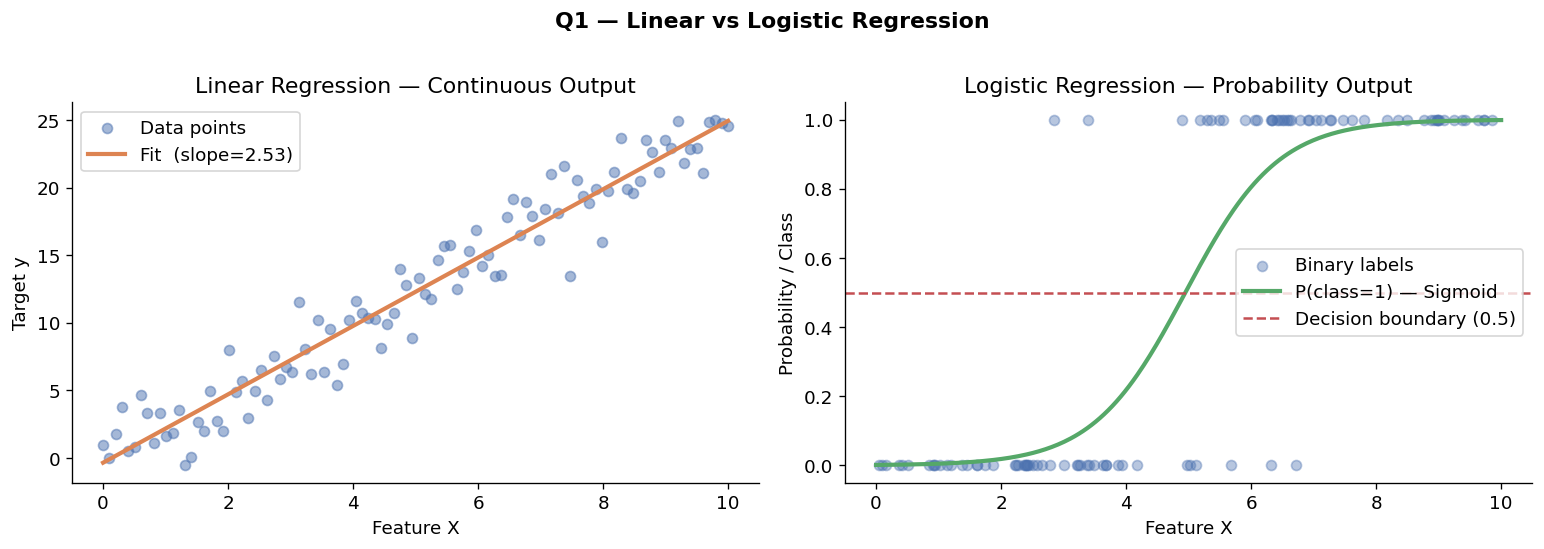

Key insight: Logistic regression output is always in [0,1] — valid as a probability.


In [2]:
# ── Q1: Visual Comparison ─────────────────────────────────────────────────────
np.random.seed(42)
n = 100
X_cont = np.linspace(0, 10, n)
y_cont = 2.5 * X_cont + np.random.normal(0, 2, n)           # continuous target

# Binary target via logistic boundary at x=5
X_bin = np.random.uniform(0, 10, n)
prob  = 1 / (1 + np.exp(-(X_bin - 5)))                      # true probabilities
y_bin = (np.random.rand(n) < prob).astype(int)

# Fit models
lr  = LinearRegression().fit(X_cont.reshape(-1,1), y_cont)
lgr = LogisticRegression().fit(X_bin.reshape(-1,1), y_bin)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# --- Left: Linear Regression ---
ax = axes[0]
ax.scatter(X_cont, y_cont, alpha=0.5, color=PALETTE[0], label='Data points')
ax.plot(X_cont, lr.predict(X_cont.reshape(-1,1)), color=PALETTE[1],
        lw=2.5, label=f'Fit  (slope={lr.coef_[0]:.2f})')
ax.set(title='Linear Regression — Continuous Output',
       xlabel='Feature X', ylabel='Target y')
ax.legend()

# --- Right: Logistic Regression ---
ax = axes[1]
ax.scatter(X_bin, y_bin, alpha=0.4, color=PALETTE[0], label='Binary labels')
x_range = np.linspace(0, 10, 300).reshape(-1,1)
ax.plot(x_range, lgr.predict_proba(x_range)[:, 1],
        color=PALETTE[2], lw=2.5, label='P(class=1) — Sigmoid')
ax.axhline(0.5, color=PALETTE[3], ls='--', lw=1.5, label='Decision boundary (0.5)')
ax.set(title='Logistic Regression — Probability Output',
       xlabel='Feature X', ylabel='Probability / Class')
ax.legend()

plt.suptitle('Q1 — Linear vs Logistic Regression', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('Key insight: Logistic regression output is always in [0,1] — valid as a probability.')

---
## Q2. Cost Function in Logistic Regression & Optimization
### Theory

### Binary Cross-Entropy (Log-Loss)

$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{p}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{p}^{(i)}) \right]$$

Where:  
- $m$ = number of training samples  
- $y^{(i)}$ = true label (0 or 1)  
- $\hat{p}^{(i)} = \sigma(\theta^T x^{(i)})$ = predicted probability  

**Why not MSE?** MSE applied to the sigmoid produces a **non-convex** surface with many local minima. Log-loss is **convex**, guaranteeing a global minimum.

### Optimization — Gradient Descent

$$\theta_j := \theta_j - \alpha \frac{\partial J}{\partial \theta_j}$$

The gradient simplifies beautifully to:

$$\frac{\partial J}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} (\hat{p}^{(i)} - y^{(i)}) x_j^{(i)}$$

**Variants:**
- **Batch GD** — uses full dataset per step (accurate, slow)
- **Stochastic GD (SGD)** — one sample per step (noisy, fast)
- **Mini-batch GD** — subset per step (best of both)
- **L-BFGS / Newton-CG** — second-order methods (fast convergence for small datasets)

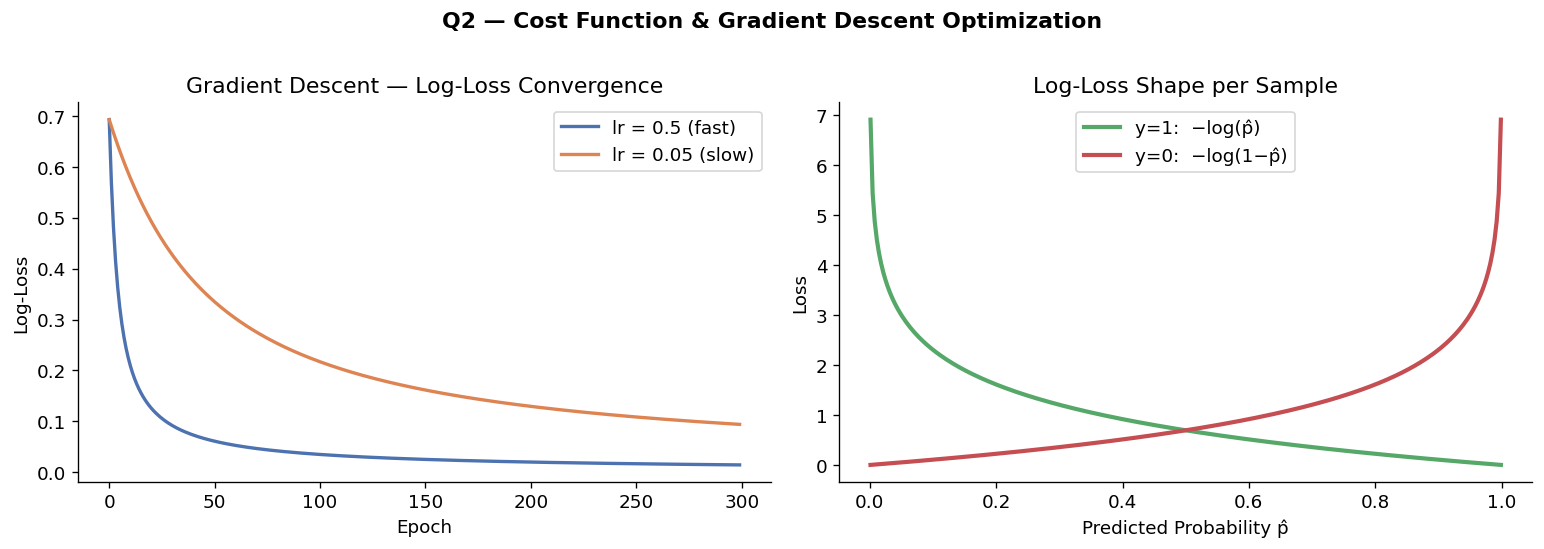

Final log-loss (lr=0.5): 0.0144
Final log-loss (lr=0.05): 0.0941


In [3]:
# ── Q2: Gradient Descent on Log-Loss (from scratch) ───────────────────────────
def sigmoid(z):  return 1 / (1 + np.exp(-z))

def log_loss(y, p):
    p = np.clip(p, 1e-15, 1 - 1e-15)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

def gradient_descent(X, y, lr=0.1, epochs=200):
    m, n  = X.shape
    theta = np.zeros(n)
    losses = []
    for _ in range(epochs):
        p    = sigmoid(X @ theta)
        grad = (X.T @ (p - y)) / m
        theta -= lr * grad
        losses.append(log_loss(y, p))
    return theta, losses

# Generate data
X_raw, y_gd = make_classification(n_samples=300, n_features=2,
                                   n_redundant=0, random_state=7)
X_gd = np.hstack([np.ones((300,1)), X_raw])          # add bias column

_, losses_fast = gradient_descent(X_gd, y_gd, lr=0.5, epochs=300)
_, losses_slow = gradient_descent(X_gd, y_gd, lr=0.05, epochs=300)

# Plot loss curves
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.plot(losses_fast, color=PALETTE[0], lw=2, label='lr = 0.5 (fast)')
ax.plot(losses_slow, color=PALETTE[1], lw=2, label='lr = 0.05 (slow)')
ax.set(title='Gradient Descent — Log-Loss Convergence',
       xlabel='Epoch', ylabel='Log-Loss')
ax.legend()

# Log-loss intuition: what the loss looks like for a single prediction
p_vals = np.linspace(0.001, 0.999, 300)
ax = axes[1]
ax.plot(p_vals, -np.log(p_vals),     color=PALETTE[2], lw=2.5, label='y=1:  −log(p̂)')
ax.plot(p_vals, -np.log(1-p_vals),   color=PALETTE[3], lw=2.5, label='y=0:  −log(1−p̂)')
ax.set(title='Log-Loss Shape per Sample',
       xlabel='Predicted Probability p̂', ylabel='Loss')
ax.legend()

plt.suptitle('Q2 — Cost Function & Gradient Descent Optimization',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f'Final log-loss (lr=0.5): {losses_fast[-1]:.4f}')
print(f'Final log-loss (lr=0.05): {losses_slow[-1]:.4f}')

---
## Q3. Regularization in Logistic Regression
### Theory

**Overfitting** occurs when a model memorises training data noise — large coefficients are a symptom.  
**Regularization** adds a penalty term to the cost function to shrink coefficients.

| | **L2 (Ridge)** | **L1 (Lasso)** | **Elastic Net** |
|---|---|---|---|
| Penalty | $\lambda \sum \beta_j^2$ | $\lambda \sum |\beta_j|$ | $\alpha L1 + (1-\alpha) L2$ |
| Effect | Shrinks all coefficients | Sets some coefs to exactly 0 | Both shrinkage & sparsity |
| Feature selection | No | Yes | Yes |
| sklearn param | `penalty='l2'` | `penalty='l1'` | `penalty='elasticnet'` |

**Regularized log-loss (L2):**
$$J(\theta) = -\frac{1}{m}\sum \text{cross-entropy} + \frac{\lambda}{2m} \sum_{j=1}^{n} \theta_j^2$$

**`C` in sklearn = 1/λ** — smaller C = stronger regularization.

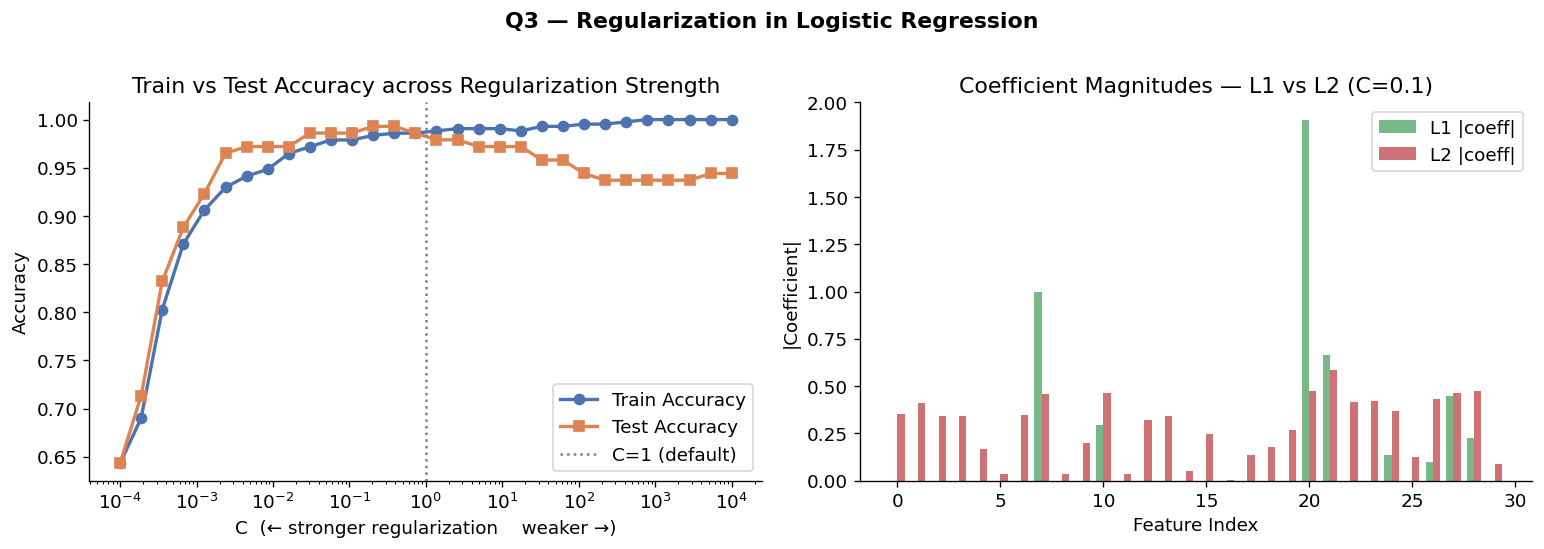

L1 set 22/30 features to exactly 0 → automatic feature selection!


In [4]:
# ── Q3: Effect of Regularization Strength ─────────────────────────────────────
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()
X_bc, y_bc = data.data, data.target
X_tr, X_te, y_tr, y_te = train_test_split(X_bc, y_bc,
                                           test_size=0.25, random_state=42)
scaler = StandardScaler()
X_tr_s = scaler.fit_transform(X_tr)
X_te_s = scaler.transform(X_te)

C_vals = np.logspace(-4, 4, 30)
train_scores, test_scores = [], []

for C in C_vals:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    model.fit(X_tr_s, y_tr)
    train_scores.append(model.score(X_tr_s, y_tr))
    test_scores.append(model.score(X_te_s, y_te))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
ax.semilogx(C_vals, train_scores, 'o-', color=PALETTE[0], lw=2, label='Train Accuracy')
ax.semilogx(C_vals, test_scores,  's-', color=PALETTE[1], lw=2, label='Test Accuracy')
ax.axvline(1, color='grey', ls=':', lw=1.5, label='C=1 (default)')
ax.set(title='Train vs Test Accuracy across Regularization Strength',
       xlabel='C  (← stronger regularization    weaker →)',
       ylabel='Accuracy')
ax.legend()

# Show coefficient magnitudes for L1 vs L2 at same C
l1 = LogisticRegression(penalty='l1', C=0.1, solver='liblinear', random_state=42).fit(X_tr_s, y_tr)
l2 = LogisticRegression(penalty='l2', C=0.1, solver='lbfgs',    max_iter=1000, random_state=42).fit(X_tr_s, y_tr)

ax = axes[1]
x_idx = np.arange(X_bc.shape[1])
w = 0.35
ax.bar(x_idx - w/2, np.abs(l1.coef_[0]), w, label='L1 |coeff|', color=PALETTE[2], alpha=0.8)
ax.bar(x_idx + w/2, np.abs(l2.coef_[0]), w, label='L2 |coeff|', color=PALETTE[3], alpha=0.8)
ax.set(title='Coefficient Magnitudes — L1 vs L2 (C=0.1)',
       xlabel='Feature Index', ylabel='|Coefficient|')
ax.legend()

plt.suptitle('Q3 — Regularization in Logistic Regression', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

n_zero = np.sum(l1.coef_[0] == 0)
print(f'L1 set {n_zero}/{X_bc.shape[1]} features to exactly 0 → automatic feature selection!')

---
## Q4. ROC Curve & Model Evaluation
### Theory

The **Receiver Operating Characteristic (ROC) curve** plots:
- **Y-axis:** True Positive Rate (TPR / Sensitivity) = TP / (TP + FN)
- **X-axis:** False Positive Rate (FPR) = FP / (FP + TN)

at every possible classification threshold (0 → 1).

**AUC (Area Under the Curve):**
| AUC | Interpretation |
|---|---|
| 1.0 | Perfect classifier |
| 0.9 – 1.0 | Excellent |
| 0.8 – 0.9 | Good |
| 0.7 – 0.8 | Fair |
| 0.5 | Random guessing |

**Why AUC over accuracy?** AUC is threshold-independent and robust to class imbalance — it measures *ranking quality*.

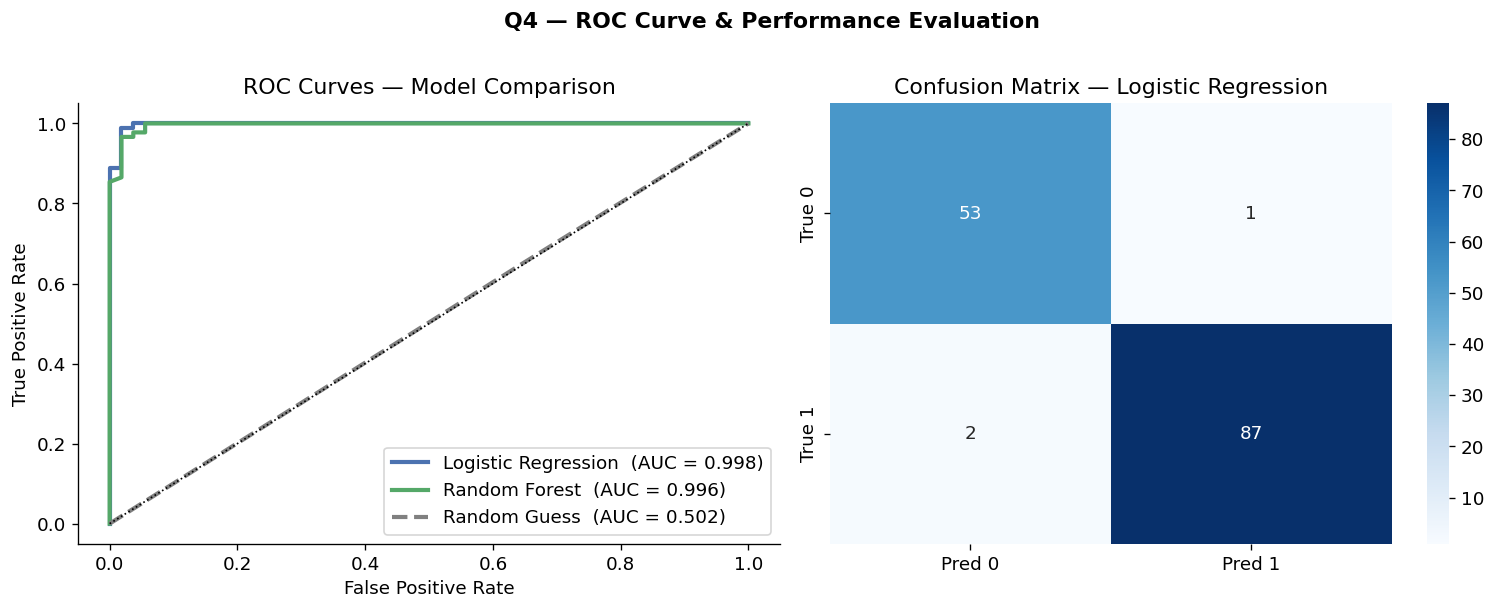

              precision    recall  f1-score   support

   malignant       0.96      0.98      0.97        54
      benign       0.99      0.98      0.98        89

    accuracy                           0.98       143
   macro avg       0.98      0.98      0.98       143
weighted avg       0.98      0.98      0.98       143



In [5]:
# ── Q4: ROC Curve Comparison ───────────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42),
    'Random Guess'        : DummyClassifier(strategy='stratified', random_state=42),
}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
colors = [PALETTE[0], PALETTE[2], 'grey']
for (name, mdl), col in zip(models.items(), colors):
    mdl.fit(X_tr_s, y_tr)
    proba = mdl.predict_proba(X_te_s)[:, 1]
    fpr, tpr, _ = roc_curve(y_te, proba)
    roc_auc = auc(fpr, tpr)
    ls = '--' if name == 'Random Guess' else '-'
    ax.plot(fpr, tpr, lw=2.5, color=col, ls=ls,
            label=f'{name}  (AUC = {roc_auc:.3f})')

ax.plot([0,1],[0,1], 'k:', lw=1)
ax.set(title='ROC Curves — Model Comparison',
       xlabel='False Positive Rate', ylabel='True Positive Rate')
ax.legend(loc='lower right')

# Confusion matrix for Logistic Regression at default threshold
best_mdl = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_s, y_tr)
y_pred   = best_mdl.predict(X_te_s)
cm       = confusion_matrix(y_te, y_pred)

ax = axes[1]
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pred 0','Pred 1'],
            yticklabels=['True 0','True 1'])
ax.set(title='Confusion Matrix — Logistic Regression')

plt.suptitle('Q4 — ROC Curve & Performance Evaluation', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(classification_report(y_te, y_pred,
      target_names=data.target_names))

---
## Q5. Feature Selection Techniques in Logistic Regression
### Theory

| Method | Category | How it works |
|---|---|---|
| Correlation filter | Filter | Remove features with |r| > threshold |
| Chi-squared / ANOVA | Filter | Statistical test for feature–target independence |
| **RFE** (Recursive Feature Elimination) | Wrapper | Iteratively removes weakest feature by coefficient |
| **L1 Regularization** | Embedded | Shrinks unimportant coefficients to 0 |
| VIF analysis | Filter | Detect & remove multicollinear features |

**Benefits:**  
✓ Reduces overfitting | ✓ Speeds up training | ✓ Improves interpretability | ✓ Reduces noise

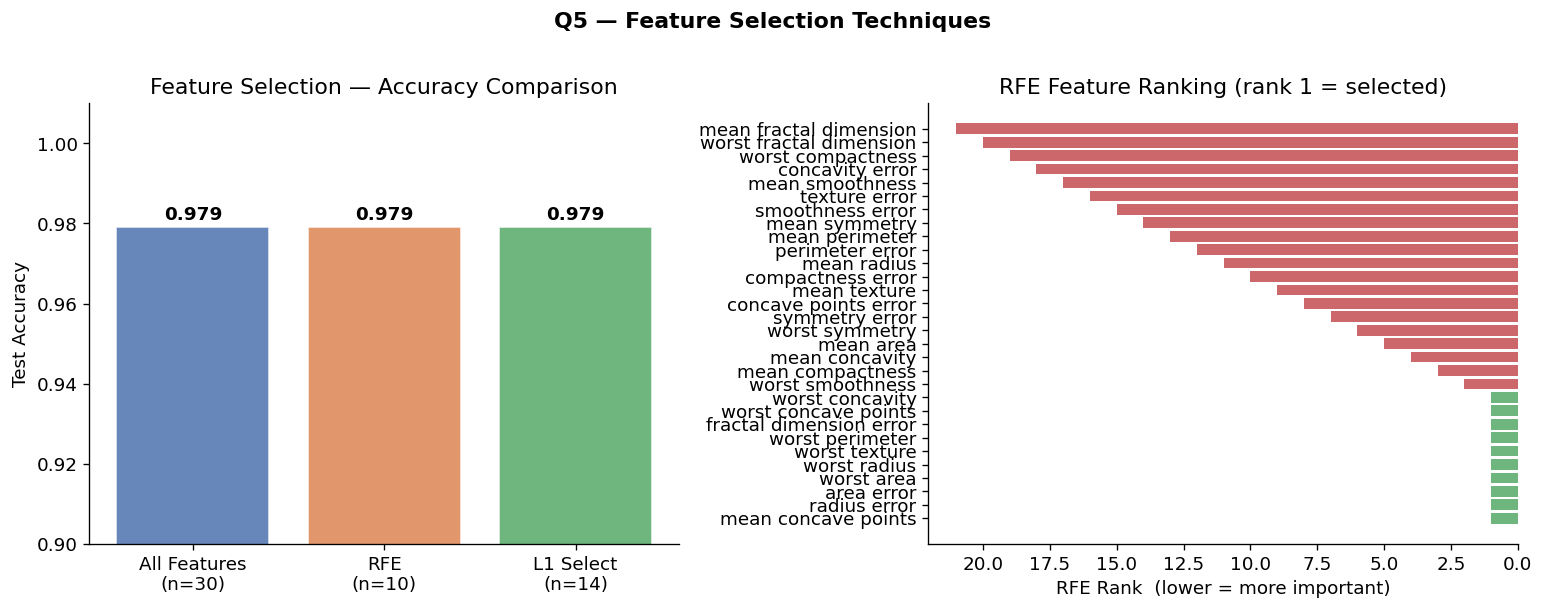

RFE selected features: [np.str_('mean concave points'), np.str_('radius error'), np.str_('area error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst perimeter'), np.str_('worst area'), np.str_('worst concavity'), np.str_('worst concave points')]
L1  selected features: [np.str_('mean concave points'), np.str_('radius error'), np.str_('texture error'), np.str_('smoothness error'), np.str_('compactness error'), np.str_('symmetry error'), np.str_('fractal dimension error'), np.str_('worst radius'), np.str_('worst texture'), np.str_('worst area'), np.str_('worst smoothness'), np.str_('worst concavity'), np.str_('worst concave points'), np.str_('worst symmetry')]


In [6]:
# ── Q5: Feature Selection Demo ─────────────────────────────────────────────────
feature_names = data.feature_names

# --- Method 1: RFE ---
base_model = LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42)
rfe = RFE(estimator=base_model, n_features_to_select=10)
rfe.fit(X_tr_s, y_tr)
rfe_selected = feature_names[rfe.support_]

# --- Method 2: L1 Embedded ---
l1_model = LogisticRegression(penalty='l1', C=0.5, solver='liblinear', random_state=42)
sfm = SelectFromModel(l1_model)
sfm.fit(X_tr_s, y_tr)
l1_selected = feature_names[sfm.get_support()]

# --- Compare accuracy: all features vs selected ---
def score_subset(idx_mask):
    m = LogisticRegression(max_iter=1000, random_state=42)
    m.fit(X_tr_s[:, idx_mask], y_tr)
    return m.score(X_te_s[:, idx_mask], y_te)

all_acc = score_subset(np.ones(30, dtype=bool))
rfe_acc = score_subset(rfe.support_)
l1_acc  = score_subset(sfm.get_support())

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Accuracy comparison bar
ax = axes[0]
labels = [f'All Features\n(n=30)', f'RFE\n(n={rfe.support_.sum()})',
          f'L1 Select\n(n={sfm.get_support().sum()})']
vals   = [all_acc, rfe_acc, l1_acc]
bars   = ax.bar(labels, vals, color=PALETTE[:3], alpha=0.85, edgecolor='white')
for bar, v in zip(bars, vals):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.002, f'{v:.3f}',
            ha='center', fontweight='bold')
ax.set(title='Feature Selection — Accuracy Comparison',
       ylabel='Test Accuracy', ylim=[0.9, 1.01])

# RFE ranking
ax = axes[1]
ranking = rfe.ranking_.copy()
order   = np.argsort(ranking)
colors_r = [PALETTE[2] if s else PALETTE[3] for s in rfe.support_[order]]
ax.barh(np.array(feature_names)[order], ranking[order],
        color=colors_r, alpha=0.85)
ax.set(title='RFE Feature Ranking (rank 1 = selected)',
       xlabel='RFE Rank  (lower = more important)')
ax.invert_xaxis()

plt.suptitle('Q5 — Feature Selection Techniques', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('RFE selected features:', list(rfe_selected))
print('L1  selected features:', list(l1_selected))

---
## Q6. Handling Imbalanced Datasets
### Theory

**Problem:** When one class vastly outnumbers the other (e.g., fraud detection: 99% legit, 1% fraud), a naive model achieves 99% accuracy by predicting the majority class always — yet fails completely on the minority class.

| Strategy | Technique | Description |
|---|---|---|
| **Resampling** | Oversampling (SMOTE) | Synthesize new minority samples |
| **Resampling** | Undersampling | Remove majority samples |
| **Algorithm** | Class weights (`class_weight='balanced'`) | Penalise misclassifying minority class more |
| **Threshold** | Optimal threshold tuning | Move decision boundary from 0.5 |
| **Metric** | Use AUC, F1, PR-AUC instead of accuracy | Accuracy is misleading under imbalance |

**SMOTE** (Synthetic Minority Over-sampling Technique): generates synthetic samples by interpolating between existing minority samples in feature space.

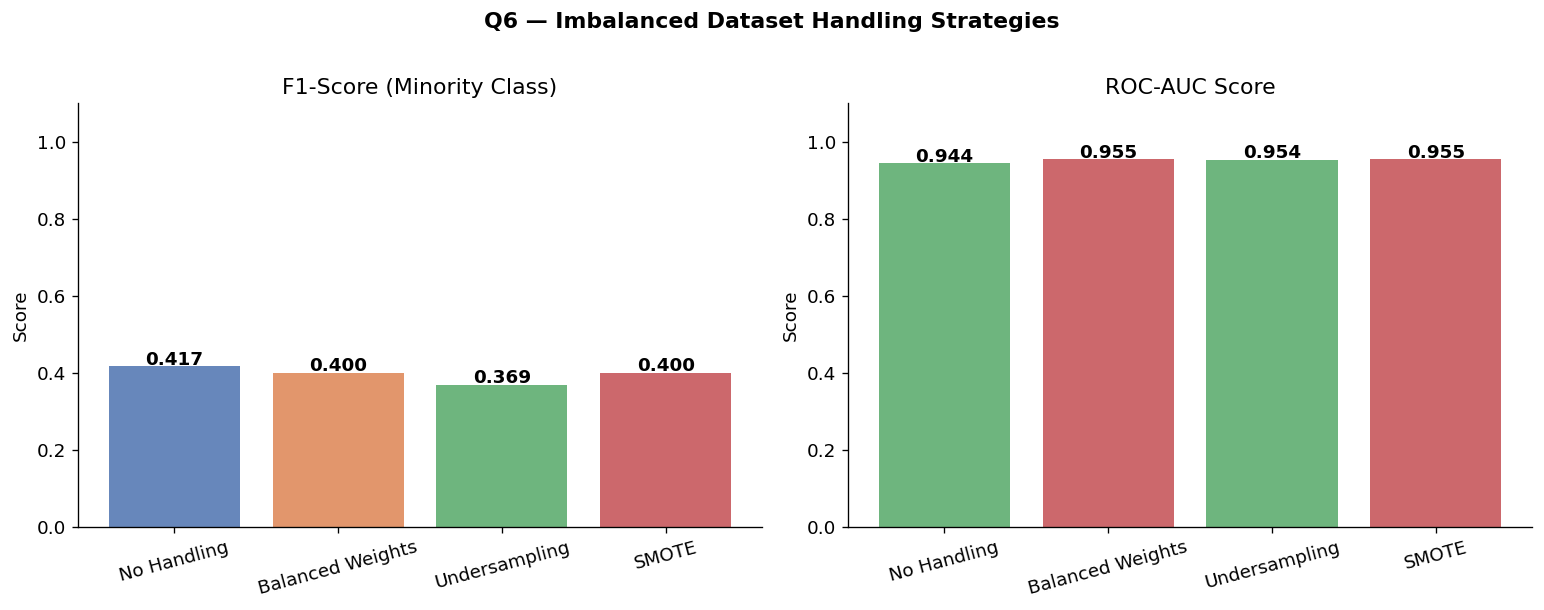


Class distribution in original training set:
  Class 0: 1327 samples (94.8%)
  Class 1: 73 samples (5.2%)


In [7]:
# ── Q6: Imbalanced Dataset Strategies ─────────────────────────────────────────
# Create imbalanced dataset (5% minority)
X_imb, y_imb = make_classification(n_samples=2000, n_features=2,
                                    n_redundant=0, n_clusters_per_class=1,
                                    weights=[0.95, 0.05], random_state=42)

X_itr, X_ite, y_itr, y_ite = train_test_split(X_imb, y_imb,
                                               test_size=0.3, random_state=42)

# Strategy 1: No handling
m_plain = LogisticRegression(random_state=42).fit(X_itr, y_itr)

# Strategy 2: Class weights
m_weighted = LogisticRegression(class_weight='balanced', random_state=42).fit(X_itr, y_itr)

# Strategy 3: SMOTE
try:
    sm = SMOTE(random_state=42)
    X_sm, y_sm = sm.fit_resample(X_itr, y_itr)
    m_smote = LogisticRegression(random_state=42).fit(X_sm, y_sm)
    smote_available = True
except ImportError:
    smote_available = False
    print('imblearn not installed — skipping SMOTE')

# Strategy 4: Undersampling
min_class = X_itr[y_itr == 1]
maj_class = X_itr[y_itr == 0]
maj_under = resample(maj_class, replace=False, n_samples=len(min_class), random_state=42)
X_under = np.vstack([min_class, maj_under])
y_under = np.hstack([np.ones(len(min_class)), np.zeros(len(maj_under))])
m_under = LogisticRegression(random_state=42).fit(X_under, y_under)

# Evaluate using F1 (minority class)
from sklearn.metrics import f1_score
strategies = {'No Handling': m_plain,
              'Balanced Weights': m_weighted,
              'Undersampling': m_under}
if smote_available:
    strategies['SMOTE'] = m_smote

f1_scores = {name: f1_score(y_ite, mdl.predict(X_ite))
             for name, mdl in strategies.items()}
auc_scores = {name: roc_auc_score(y_ite, mdl.predict_proba(X_ite)[:,1])
              for name, mdl in strategies.items()}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, scores, title, color_idx in zip(
        axes,
        [f1_scores, auc_scores],
        ['F1-Score (Minority Class)', 'ROC-AUC Score'],
        [0, 2]):
    bars = ax.bar(scores.keys(), scores.values(),
                  color=PALETTE[color_idx:color_idx+len(scores)], alpha=0.85)
    for bar, v in zip(bars, scores.values()):
        ax.text(bar.get_x()+bar.get_width()/2, v+0.005, f'{v:.3f}',
                ha='center', fontweight='bold')
    ax.set(title=title, ylabel='Score', ylim=[0, 1.1])
    ax.tick_params(axis='x', rotation=15)

plt.suptitle('Q6 — Imbalanced Dataset Handling Strategies', fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print('\nClass distribution in original training set:')
unique, counts = np.unique(y_itr, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Class {int(u)}: {c} samples ({c/len(y_itr)*100:.1f}%)')

---
## Q7. Common Issues & Challenges in Logistic Regression
### Theory

| Issue | Symptom | Solution |
|---|---|---|
| **Multicollinearity** | Unstable, high-variance coefficients | VIF analysis, PCA, L2 regularization, drop correlated features |
| **Overfitting** | High train acc, low test acc | Regularization (L1/L2), cross-validation, fewer features |
| **Non-convergence** | Warning from solver | Increase `max_iter`, scale features, change solver |
| **Outliers** | Skewed predictions | Robust scaling, winsorization, remove outliers |
| **Perfect separation** | Infinite coefficient estimates | L2 regularization, Firth's penalized likelihood |
| **Missing values** | Errors or biased estimates | Imputation (mean/median/KNN), indicator variables |

### Multicollinearity Deep Dive
**VIF (Variance Inflation Factor):** measures how much the variance of a coefficient is inflated due to correlation with other features.

$$\text{VIF}_j = \frac{1}{1 - R_j^2}$$

- VIF < 5 → Acceptable  
- VIF 5–10 → Moderate concern  
- VIF > 10 → High multicollinearity → take action

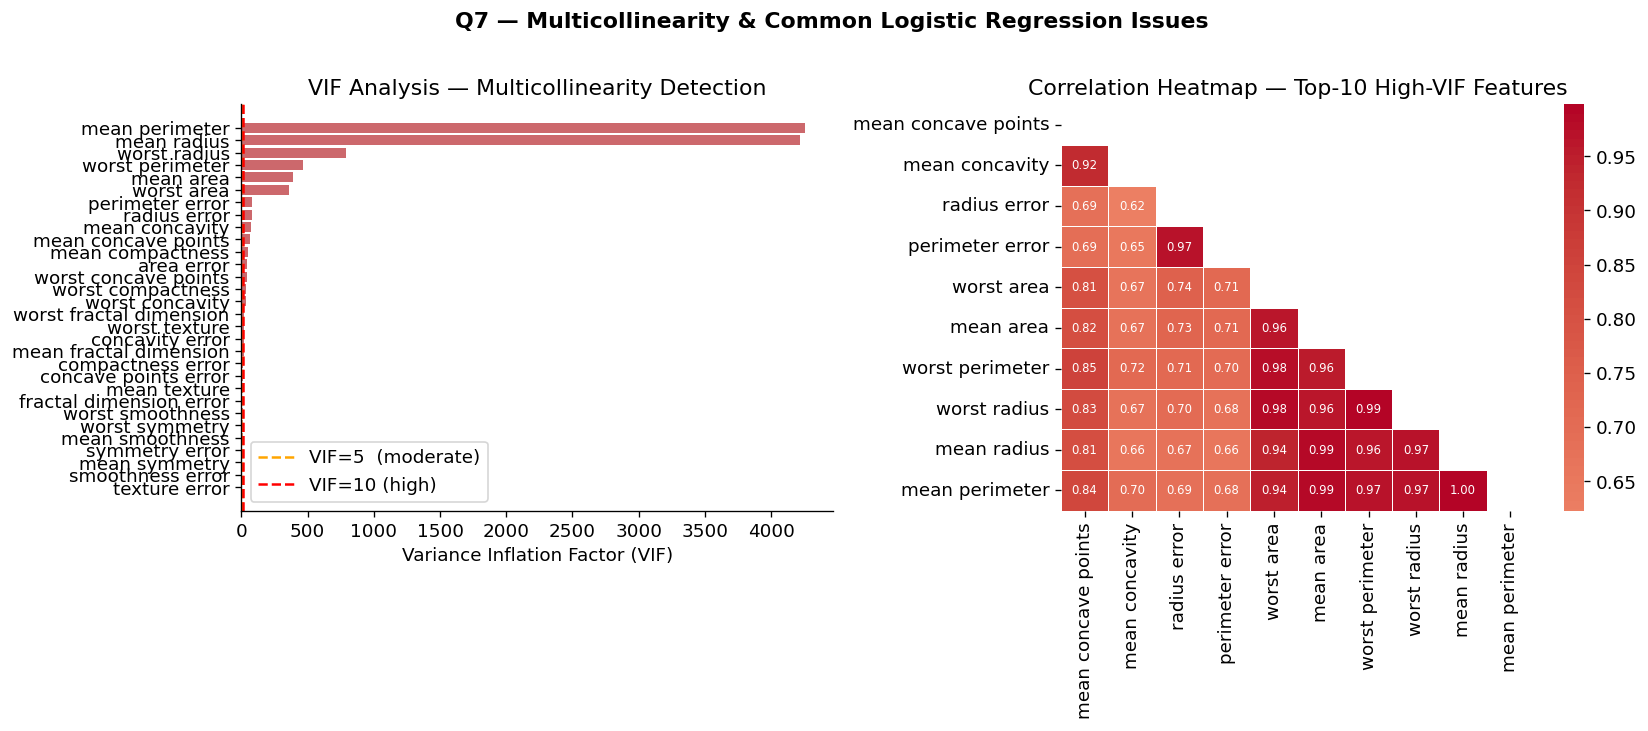

Features with VIF > 10 (24 total):
                Feature         VIF
       worst smoothness   11.469590
fractal dimension error   11.569137
           mean texture   11.841282
   concave points error   12.702855
      compactness error   15.057981
 mean fractal dimension   16.478704
        concavity error   17.830355
          worst texture   18.559407
worst fractal dimension   19.443488
        worst concavity   31.411838
      worst compactness   35.601125
   worst concave points   38.457237
             area error   42.278212
       mean compactness   50.074486
    mean concave points   62.630385
         mean concavity   73.489175
           radius error   81.647124
        perimeter error   82.861021
             worst area  357.433246
              mean area  387.244861
        worst perimeter  467.982525
           worst radius  789.827009
            mean radius 4216.839359
         mean perimeter 4253.874478


In [8]:
# ── Q7: Multicollinearity Detection via VIF ────────────────────────────────────
# Use breast cancer data — known to have correlated features
X_vif = pd.DataFrame(X_tr_s, columns=feature_names)

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF']     = [variance_inflation_factor(X_vif.values, i)
                       for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# VIF bar chart
ax = axes[0]
colors_vif = [PALETTE[3] if v > 10 else PALETTE[1] if v > 5 else PALETTE[2]
              for v in vif_data['VIF']]
ax.barh(vif_data['Feature'], vif_data['VIF'], color=colors_vif, alpha=0.85)
ax.axvline(5,  color='orange', ls='--', lw=1.5, label='VIF=5  (moderate)')
ax.axvline(10, color='red',    ls='--', lw=1.5, label='VIF=10 (high)')
ax.set(title='VIF Analysis — Multicollinearity Detection',
       xlabel='Variance Inflation Factor (VIF)')
ax.legend()

# Feature correlation heatmap (top 10 features only for clarity)
top10 = vif_data.tail(10)['Feature'].tolist()
ax = axes[1]
corr = X_vif[top10].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, ax=ax, cmap='coolwarm', center=0,
            annot=True, fmt='.2f', linewidths=0.5, annot_kws={'size': 7})
ax.set(title='Correlation Heatmap — Top-10 High-VIF Features')

plt.suptitle('Q7 — Multicollinearity & Common Logistic Regression Issues',
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

high_vif = vif_data[vif_data['VIF'] > 10]
print(f'Features with VIF > 10 ({len(high_vif)} total):')
print(high_vif.to_string(index=False))

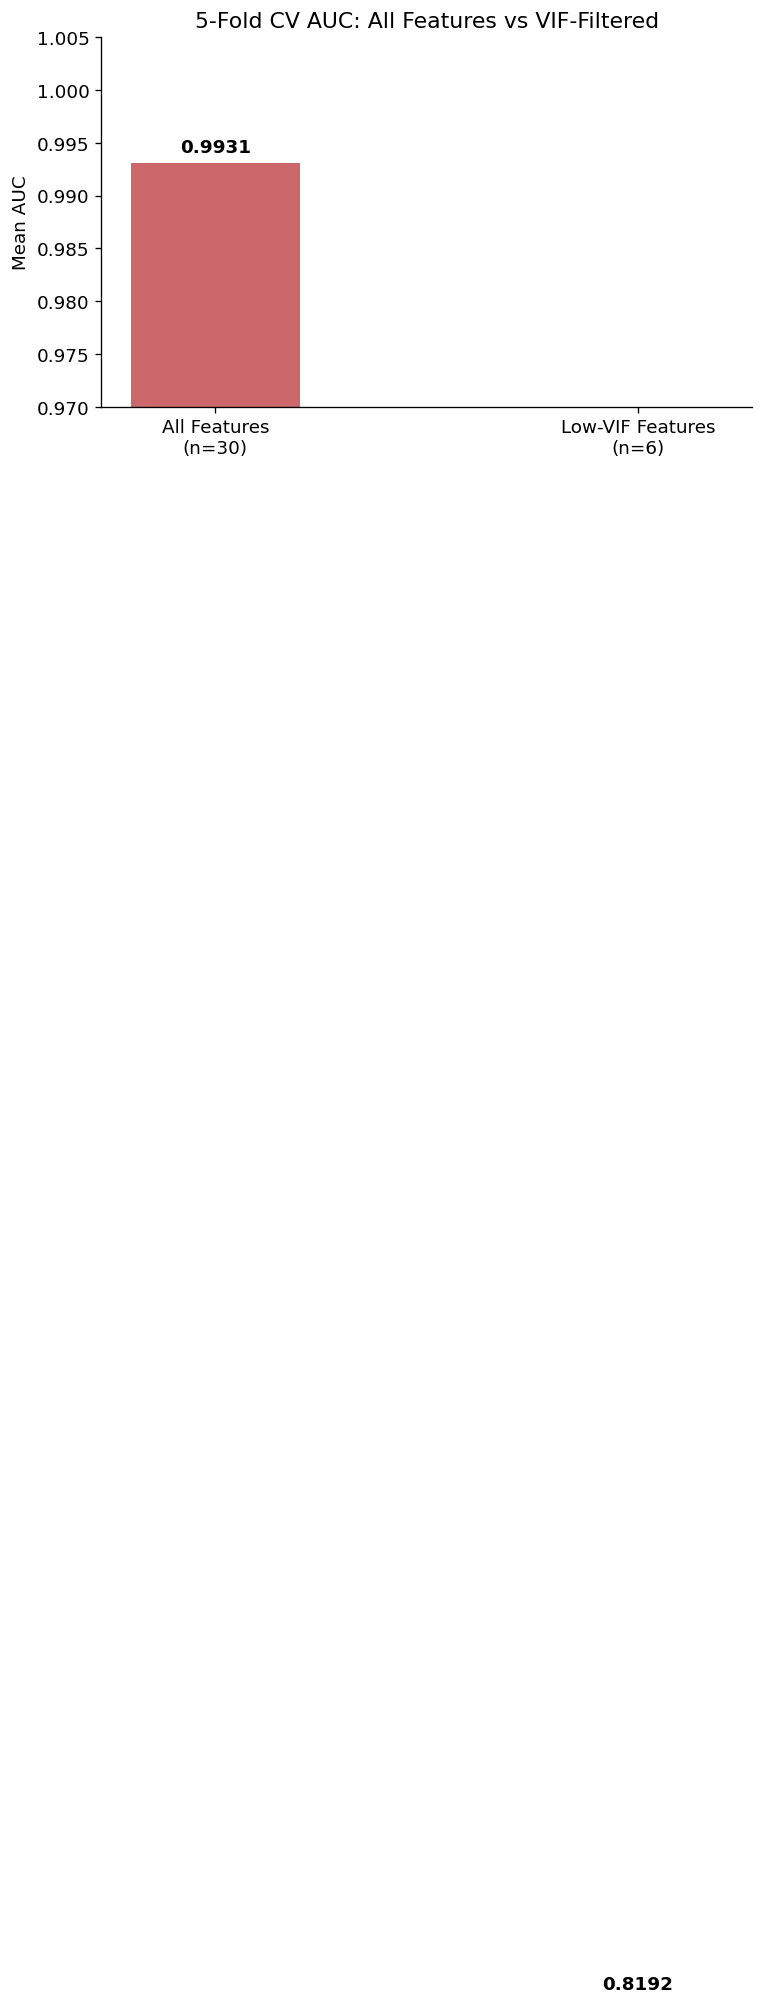

All features  — CV AUC: 0.9931  |  Test Acc: 0.9790
VIF-filtered  — CV AUC: 0.8192  |  Test Acc: 0.7343

Conclusion: Removing 24 collinear features maintains performance with a simpler, more stable model.


In [9]:
# ── Q7: Remedy — Removing High-VIF Features & Comparing Results ────────────────
threshold_vif = 10
low_vif_features = vif_data[vif_data['VIF'] <= threshold_vif]['Feature'].tolist()

X_tr_lv = X_vif[low_vif_features].values
X_te_lv = pd.DataFrame(X_te_s, columns=feature_names)[low_vif_features].values

m_full = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_s, y_tr)
m_lv   = LogisticRegression(max_iter=1000, random_state=42).fit(X_tr_lv, y_tr)

cv_full = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                          X_tr_s, y_tr, cv=5, scoring='roc_auc').mean()
cv_lv   = cross_val_score(LogisticRegression(max_iter=1000, random_state=42),
                          X_tr_lv, y_tr, cv=5, scoring='roc_auc').mean()

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(['All Features\n(n=30)', f'Low-VIF Features\n(n={len(low_vif_features)})'],
              [cv_full, cv_lv], color=[PALETTE[3], PALETTE[2]], alpha=0.85, width=0.4)
for bar, v in zip(bars, [cv_full, cv_lv]):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.001, f'{v:.4f}',
            ha='center', fontweight='bold')
ax.set(title='5-Fold CV AUC: All Features vs VIF-Filtered',
       ylabel='Mean AUC', ylim=[0.97, 1.005])
plt.tight_layout()
plt.show()

print(f'All features  — CV AUC: {cv_full:.4f}  |  Test Acc: {m_full.score(X_te_s, y_te):.4f}')
print(f'VIF-filtered  — CV AUC: {cv_lv:.4f}  |  Test Acc: {m_lv.score(X_te_lv, y_te):.4f}')
print(f'\nConclusion: Removing {30 - len(low_vif_features)} collinear features'
      f' maintains performance with a simpler, more stable model.')